In [18]:
#Phân loại đa lớp cảnh vật tự nhiên sử dụng mô hình học sâu trên bộ dữ liệu Intel Image Classification 
#Đồ án DL & Applications
#NCS Cáp Phạm Đình Thăng
#2025


In [19]:
# =====================================================
# 1️⃣ Import thư viện
# =====================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time, copy, os
from tqdm import tqdm
from torchvision.models import vit_b_16, ViT_B_16_Weights
import pandas as pd #thư viện làm việc với dữ liệu dạng bảng (dataframe, csv,...)
import numpy as np #thư viện toán học để xử lý dữ liệu số
import matplotlib.pyplot as plt #thư viện hỗ trợ vẽ biểu đồ
import seaborn as sns#hỗ trợ vẽ biểu đồ

In [20]:
# =====================================================
# 2️⃣ Kiểm tra GPU
# =====================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

# =====================================================
# 3️⃣ Đọc dữ liệu Intel Image Dataset
# =====================================================
data_dir = "data"
train_dir = os.path.join(data_dir, "seg_train", "seg_train")
test_dir = os.path.join(data_dir, "seg_test", "seg_test")
pred_dir = os.path.join(data_dir, "seg_pred", "seg_pred")

img_size = 224
batch_size = 32

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
}


✅ Using device: cuda


In [21]:
# Load train + val
full_train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
train_idx, val_idx = train_test_split(list(range(len(full_train_dataset))), test_size=0.2, random_state=42)
train_dataset = Subset(full_train_dataset, train_idx)
val_dataset = Subset(full_train_dataset, val_idx)

# Load test
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['test'])

# DataLoaders
dataloaders = {
    'train': DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2),
    'val': DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2),
    'test': DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
}

class_names = full_train_dataset.classes
num_classes = len(class_names)

print(f"📂 Classes: {class_names}")
print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)} | Test size: {len(test_dataset)}")

📂 Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train size: 11227 | Val size: 2807 | Test size: 3000


In [ ]:
plt.bar(df_train['label_train'].value_counts().index,df_train['label_train'].value_counts(),color=color)
plt.title('Train Data Distribution')
plt.show()

In [16]:
def build_model(model_name="resnet50", num_classes=6, freeze=True):
    model_name = model_name.lower()

    if model_name == "vgg16":
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
        if freeze:
            for p in model.features.parameters():
                p.requires_grad = False

    elif model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
        if freeze:
            for p in model.layer1.parameters():
                p.requires_grad = False
            for p in model.layer2.parameters():
                p.requires_grad = False
            for p in model.layer3.parameters():
                p.requires_grad = False
            for p in model.layer4.parameters():
                p.requires_grad = False

    elif model_name == "mobilenet":
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
        if freeze:
            for p in model.features.parameters():
                p.requires_grad = False

    elif model_name == "efficientnet":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
        if freeze:
            for p in model.features.parameters():
                p.requires_grad = False

    elif model_name == "vit":
        model = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)
        in_features = model.heads.head.in_features
        model.heads.head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
        if freeze:
            for p in model.encoder.parameters():
                p.requires_grad = False

    else:
        raise ValueError("❌ Model name must be one of: vgg16, resnet50, mobilenet, efficientnet, vit")

    return model.to(device)


In [17]:
# =====================================================
# 5️⃣ Training + Evaluation
# =====================================================
def train_and_evaluate(model_name, num_epochs=10, lr=1e-4):
    model = build_model(model_name, num_classes=num_classes, freeze=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    train_acc_history, val_acc_history = [], []

    for epoch in range(num_epochs):
        print(f"\n🚀 Epoch {epoch+1}/{num_epochs}")
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss, running_corrects = 0.0, 0
            for inputs, labels in tqdm(dataloaders[phase], desc=phase):
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)
            print(f"{phase} Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

            if phase == 'val':
                val_acc_history.append(epoch_acc)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
            else:
                train_acc_history.append(epoch_acc)

        scheduler.step()

    print(f"\n✅ Best val Acc: {best_acc:.4f}")
    model.load_state_dict(best_model_wts)
    torch.save(model.state_dict(), f"{model_name}_best.pt")
    print(f"💾 Model saved to {model_name}_best.pt")

    # Plot Accuracy
    plt.figure(figsize=(6,4))
    plt.plot([a.cpu() for a in train_acc_history], label='Train Acc')
    plt.plot([a.cpu() for a in val_acc_history], label='Val Acc')
    plt.title(f"{model_name.upper()} Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    return model, best_acc



🏋️ Training VGG16

🚀 Epoch 1/10


train: 100%|█████████████████████████████████████████████████████████████████████████| 351/351 [00:46<00:00,  7.55it/s]


train Loss: 0.3932 | Acc: 0.8589


val: 100%|█████████████████████████████████████████████████████████████████████████████| 88/88 [00:14<00:00,  6.29it/s]


val Loss: 0.2574 | Acc: 0.9106

🚀 Epoch 2/10


...

val Loss: 0.2122 | Acc: 0.9241

🚀 Epoch 10/10


train: 100%|█████████████████████████████████████████████████████████████████████████| 351/351 [00:48<00:00,  7.28it/s]


train Loss: 0.1362 | Acc: 0.9512


val: 100%|█████████████████████████████████████████████████████████████████████████████| 88/88 [00:15<00:00,  5.61it/s]


val Loss: 0.2167 | Acc: 0.9270

✅ Best val Acc: 0.9298
💾 Model saved to vgg16_best.pt


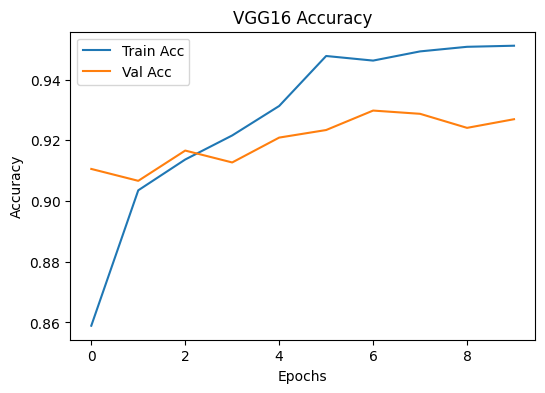


🏋️ Training RESNET50

🚀 Epoch 1/10


train: 100%|█████████████████████████████████████████████████████████████████████████| 351/351 [00:51<00:00,  6.87it/s]


train Loss: 0.7667 | Acc: 0.7766


val: 100%|█████████████████████████████████████████████████████████████████████████████| 88/88 [00:15<00:00,  5.63it/s]


val Loss: 0.4141 | Acc: 0.8646

🚀 Epoch 2/10


...

val Loss: 0.2545 | Acc: 0.9134

🚀 Epoch 10/10


train: 100%|█████████████████████████████████████████████████████████████████████████| 351/351 [00:51<00:00,  6.78it/s]


train Loss: 0.2921 | Acc: 0.8948


val: 100%|█████████████████████████████████████████████████████████████████████████████| 88/88 [00:16<00:00,  5.46it/s]


val Loss: 0.2550 | Acc: 0.9145

✅ Best val Acc: 0.9145
💾 Model saved to resnet50_best.pt


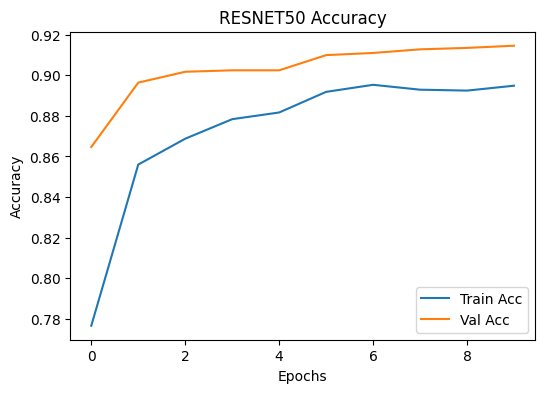


🏋️ Training MOBILENET


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\TMS/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth
100%|█████████████████████████████████████████████████████████████████████████████| 13.6M/13.6M [00:02<00:00, 5.74MB/s]



🚀 Epoch 1/10


train: 100%|█████████████████████████████████████████████████████████████████████████| 351/351 [00:45<00:00,  7.80it/s]


train Loss: 0.8242 | Acc: 0.7437


...

val Loss: 0.2866 | Acc: 0.9002

🚀 Epoch 10/10


train: 100%|█████████████████████████████████████████████████████████████████████████| 351/351 [00:37<00:00,  9.41it/s]


train Loss: 0.3473 | Acc: 0.8723


val: 100%|█████████████████████████████████████████████████████████████████████████████| 88/88 [00:14<00:00,  6.25it/s]


val Loss: 0.2882 | Acc: 0.8910

✅ Best val Acc: 0.9002
💾 Model saved to mobilenet_best.pt


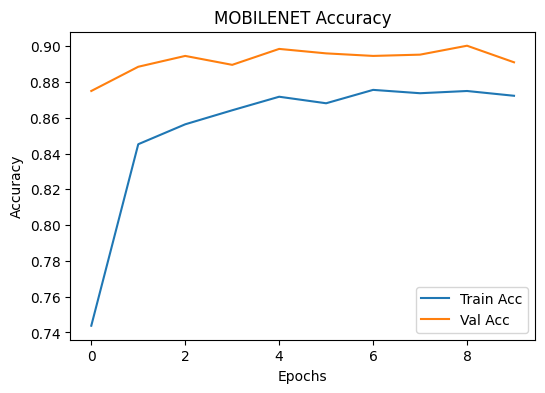


🏋️ Training EFFICIENTNET


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\TMS/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|█████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:03<00:00, 6.22MB/s]



🚀 Epoch 1/10


train: 100%|█████████████████████████████████████████████████████████████████████████| 351/351 [00:38<00:00,  9.08it/s]


train Loss: 0.9799 | Acc: 0.7278


...

val Loss: 0.3221 | Acc: 0.8888

🚀 Epoch 10/10


train: 100%|█████████████████████████████████████████████████████████████████████████| 351/351 [00:37<00:00,  9.27it/s]


train Loss: 0.3926 | Acc: 0.8605


val: 100%|█████████████████████████████████████████████████████████████████████████████| 88/88 [00:13<00:00,  6.58it/s]


val Loss: 0.3339 | Acc: 0.8849

✅ Best val Acc: 0.8949
💾 Model saved to efficientnet_best.pt


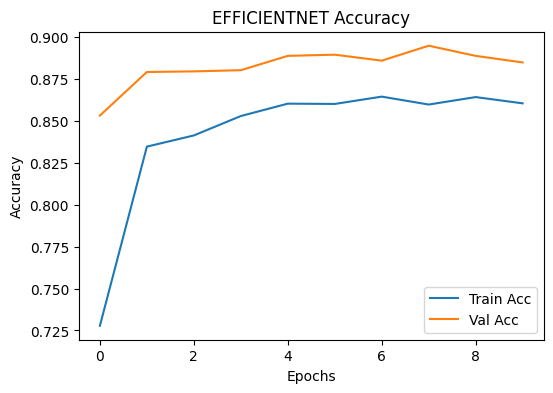


🏋️ Training VIT


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to C:\Users\TMS/.cache\torch\hub\checkpoints\vit_b_16-c867db91.pth
100%|███████████████████████████████████████████████████████████████████████████████| 330M/330M [00:55<00:00, 6.23MB/s]



🚀 Epoch 1/10


train: 100%|█████████████████████████████████████████████████████████████████████████| 351/351 [02:48<00:00,  2.08it/s]


train Loss: 0.5191 | Acc: 0.8471


...

val Loss: 0.1988 | Acc: 0.9302

🚀 Epoch 10/10


train: 100%|█████████████████████████████████████████████████████████████████████████| 351/351 [02:52<00:00,  2.04it/s]


train Loss: 0.1640 | Acc: 0.9423


val: 100%|█████████████████████████████████████████████████████████████████████████████| 88/88 [00:20<00:00,  4.27it/s]


val Loss: 0.1907 | Acc: 0.9291

✅ Best val Acc: 0.9355
💾 Model saved to vit_best.pt


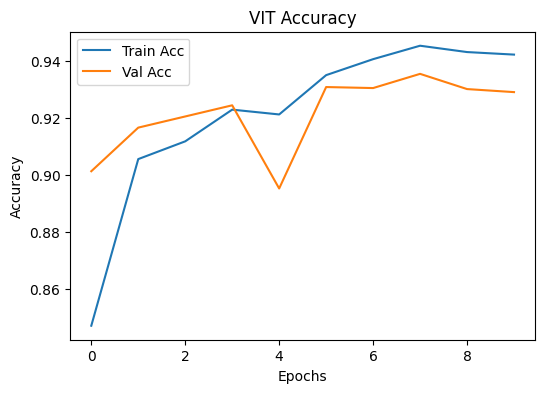

🏁 Final results:
VGG16           | Best Val Acc: 0.9298
RESNET50        | Best Val Acc: 0.9145
MOBILENET       | Best Val Acc: 0.9002
EFFICIENTNET    | Best Val Acc: 0.8949
VIT             | Best Val Acc: 0.9355


In [18]:
# =====================================================
# 6️⃣ Train tất cả các model
# =====================================================
models_to_train = ["vgg16", "resnet50", "mobilenet", "efficientnet", "vit"]
results = {}

for m in models_to_train:
    print(f"\n============================")
    print(f"🏋️ Training {m.upper()}")
    print(f"============================")
    model, acc = train_and_evaluate(m, num_epochs=10)
    results[m] = acc.item()

print("🏁 Final results:")
for k, v in results.items():
    print(f"{k.upper():<15} | Best Val Acc: {v:.4f}")

In [1]:
# ======================================================
# 🧠 CNN IMAGE CLASSIFICATION (Intel Dataset - Train/Val/Test)
# ======================================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import os
import time

# ======================================================
# 1️⃣ CẤU HÌNH CHUNG
# ======================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using device: {device}")

# Đường dẫn dataset
data_dir = "data"
train_dir = os.path.join(data_dir, "seg_train", "seg_train")
test_dir = os.path.join(data_dir, "seg_test", "seg_test")
pred_dir = os.path.join(data_dir, "seg_pred", "seg_pred")

# Tham số
img_size = 224
batch_size = 32
num_classes = 6   # Intel dataset có 6 lớp
epochs = 10
learning_rate = 0.001

# ======================================================
# 2️⃣ TIỀN XỬ LÝ DỮ LIỆU
# ======================================================
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
}

# ======================================================
# 3️⃣ CHIA DỮ LIỆU TRAIN / VAL / TEST
# ======================================================
full_train_dataset = datasets.ImageFolder(root=train_dir, transform=data_transforms['train'])

# Chia 80% train, 20% val
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_data, val_data = random_split(full_train_dataset, [train_size, val_size])

# Gán transform khác nhau (train có augment, val không)
val_data.dataset.transform = data_transforms['val']

# Test set riêng biệt
test_data = datasets.ImageFolder(root=test_dir, transform=data_transforms['test'])

# DataLoader
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print(f"📂 Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

# ======================================================
# 4️⃣ KIẾN TRÚC MÔ HÌNH CNN
# ======================================================
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        # Feature Extraction
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)

        # Fully Connected
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * (img_size // 8) * (img_size // 8), 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = self.pool3(x)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# ======================================================
# 5️⃣ KHỞI TẠO MODEL, LOSS, OPTIMIZER
# ======================================================
model = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# ======================================================
# 6️⃣ HÀM TRAIN + VALIDATE
# ======================================================
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs):
    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / val_total

        elapsed = time.time() - start_time
        print(f"📅 Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.3f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.3f} | "
              f"🕒 {elapsed:.1f}s")

    print("✅ Training completed!")

# ======================================================
# 7️⃣ TRAIN MODEL
# ======================================================
train_model(model, train_loader, val_loader, criterion, optimizer, epochs)

# ======================================================
# 8️⃣ TEST CUỐI CÙNG
# ======================================================
def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    print(f"🎯 Test Accuracy: {100 * correct / total:.2f}%")

evaluate_model(model, test_loader)

# ======================================================
# 9️⃣ LƯU MÔ HÌNH
# ======================================================
torch.save(model.state_dict(), "cnn_intel_best.pt")
print("💾 Model saved to cnn_intel_best.pt")


🚀 Using device: cuda
📂 Train: 11227 | Val: 2807 | Test: 3000
📅 Epoch [1/15] Train Loss: 1.0200, Acc: 0.613 | Val Loss: 0.7295, Acc: 0.736 | 🕒 222.5s
📅 Epoch [2/15] Train Loss: 0.6616, Acc: 0.767 | Val Loss: 0.5328, Acc: 0.808 | 🕒 111.0s
📅 Epoch [3/15] Train Loss: 0.4886, Acc: 0.827 | Val Loss: 0.5043, Acc: 0.824 | 🕒 110.5s
📅 Epoch [4/15] Train Loss: 0.3400, Acc: 0.880 | Val Loss: 0.4925, Acc: 0.829 | 🕒 111.0s
📅 Epoch [5/15] Train Loss: 0.2424, Acc: 0.915 | Val Loss: 0.7386, Acc: 0.773 | 🕒 112.5s
📅 Epoch [6/15] Train Loss: 0.1643, Acc: 0.944 | Val Loss: 0.6877, Acc: 0.811 | 🕒 109.7s
📅 Epoch [7/15] Train Loss: 0.1245, Acc: 0.957 | Val Loss: 0.7476, Acc: 0.813 | 🕒 110.1s
📅 Epoch [8/15] Train Loss: 0.1172, Acc: 0.963 | Val Loss: 0.7626, Acc: 0.812 | 🕒 109.0s
📅 Epoch [9/15] Train Loss: 0.0963, Acc: 0.969 | Val Loss: 0.9236, Acc: 0.803 | 🕒 105.8s
📅 Epoch [10/15] Train Loss: 0.0859, Acc: 0.972 | Val Loss: 0.9075, Acc: 0.821 | 🕒 150.8s
📅 Epoch [11/15] Train Loss: nan, Acc: 0.354 | Val Loss: na

In [5]:
# ======================================================
# 🧠 EVALUATE TRAINED CNN MODEL (Intel Dataset)
# ======================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import os

# ======================================================
# 1️⃣ CẤU HÌNH CHUNG
# ======================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using device: {device}")

# Đường dẫn dataset & model
data_dir = "data"
test_dir = os.path.join(data_dir, "seg_test", "seg_test")
model_path = "cnn_intel_best.pt"

img_size = 224
batch_size = 32
num_classes = 6  # Intel dataset có 6 lớp

# ======================================================
# 2️⃣ TIỀN XỬ LÝ DỮ LIỆU TEST
# ======================================================
data_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_data = datasets.ImageFolder(root=test_dir, transform=data_transform)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
class_names = test_data.classes
print(f"📂 Test samples: {len(test_data)} | Classes: {class_names}")

# ======================================================
# 3️⃣ ĐỊNH NGHĨA KIẾN TRÚC MÔ HÌNH CNN
# ======================================================
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * (img_size // 8) * (img_size // 8), 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = self.pool3(x)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# ======================================================
# 4️⃣ LOAD MÔ HÌNH HUẤN LUYỆN
# ======================================================
model = SimpleCNN(num_classes=num_classes).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print(f"✅ Loaded trained model from: {model_path}")

# ======================================================
# 5️⃣ HÀM ĐÁNH GIÁ HIỆU NĂNG
# ======================================================
def evaluate_metrics(model, dataloader, class_names, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 🧮 Tính các chỉ số
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    print("\n📊 Evaluation Metrics on Test Set:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

    # Báo cáo chi tiết từng lớp
    print("\nDetailed Classification Report:\n",
          classification_report(all_labels, all_preds, target_names=class_names))

    # Ma trận nhầm lẫn
    print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))

    return acc, precision, recall, f1

# ======================================================
# 6️⃣ CHẠY ĐÁNH GIÁ
# ======================================================
acc, prec, rec, f1 = evaluate_metrics(model, test_loader, class_names, device)


🚀 Using device: cuda
📂 Test samples: 3000 | Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


C:\Users\TMS\AppData\Local\Temp\ipykernel_12632\1662003635.py:79: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=dev

✅ Loaded trained model from: cnn_intel_best.pt

📊 Evaluation Metrics on Test Set:
Accuracy:  0.1457
Precision: 0.0243
Recall:    0.1667
F1-score:  0.0424

Detailed Classification Report:
               precision    recall  f1-score   support

   buildings       0.15      1.00      0.25       437
      forest       0.00      0.00      0.00       474
     glacier       0.00      0.00      0.00       553
    mountain       0.00      0.00      0.00       525
         sea       0.00      0.00      0.00       510
      street       0.00      0.00      0.00       501

    accuracy                           0.15      3000
   macro avg       0.02      0.17      0.04      3000
weighted avg       0.02      0.15      0.04      3000

Confusion Matrix:
 [[437   0   0   0   0   0]
 [474   0   0   0   0   0]
 [553   0   0   0   0   0]
 [525   0   0   0   0   0]
 [510   0   0   0   0   0]
 [501   0   0   0   0   0]]


C:\Users\TMS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\TMS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\TMS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier